In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("train.csv")

In [22]:
print("=== задание 2 ===")

# сколько строк и столбцов
rows, cols = df.shape
print(f"строк: {rows}")
print(f"колонок: {cols}")

# выводим имена колонок
print("\nимена колонок:")
print(df.columns.tolist())

# смотрим типы данных
print("\nтипы данных:")
print(df.dtypes)


=== задание 2 ===
строк: 891
колонок: 12

имена колонок:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [23]:
print("=== задание 3 ===")

# сколько людей в каждом классе
print("люди по классам:")
print(df["Pclass"].value_counts())

# сколько мужчин и женщин
print("\nмужики и женщины:")
print(df["Sex"].value_counts())

# делим людей по возрасту
def get_age_group(age):
    if pd.isna(age):
        return "хз"
    elif age < 18:
        return "дети"
    elif age < 60:
        return "взрослые"
    else:
        return "старики"

df["Age_Group"] = df["Age"].apply(get_age_group)
print("\nгруппы по возрасту:")
print(df["Age_Group"].value_counts())

# средний и медианный возраст
print(f"\nсредний возраст: {df['Age'].mean():.2f}")
print(f"медианный возраст: {df['Age'].median():.1f}")

# средняя цена билета
print(f"\nсредний билет стоит: {df['Fare'].mean():.2f}")


=== задание 3 ===
люди по классам:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

мужики и женщины:
Sex
male      577
female    314
Name: count, dtype: int64

группы по возрасту:
Age_Group
взрослые    575
хз          177
дети        113
старики      26
Name: count, dtype: int64

средний возраст: 29.70
медианный возраст: 28.0

средний билет стоит: 32.20


In [24]:
print("=== задание 4 ===")

# средняя цена билета для каждого класса
print("цена билета по классам:")
print(df.groupby("Pclass")["Fare"].mean())

# средний возраст по классам
print("\nсредний возраст по классам:")
print(df.groupby("Pclass")["Age"].mean())

# сколько м и ж в каждом классе
print("\nмужики и женщины по классам:")
print(df.groupby(["Pclass", "Sex"]).size().unstack())

# где было больше всего народа
most_populated = df["Pclass"].value_counts().idxmax()
print(f"\nбольше всего толпы было в классе: {most_populated}")

# ищем самый дорогой билет
rich_passenger = df[df["Fare"] == df["Fare"].max()].iloc[0]
print("\nинфа про самый дорогой билет:")
print(f"класс: {rich_passenger['Pclass']}")
print(f"возраст: {rich_passenger['Age']}")
print(f"пол: {rich_passenger['Sex']}")
print(f"выжил или нет 1 да 0 нет: {rich_passenger['Survived']}")


=== задание 4 ===
цена билета по классам:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

средний возраст по классам:
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

мужики и женщины по классам:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347

больше всего толпы было в классе: 3

инфа про самый дорогой билет:
класс: 1
возраст: 35.0
пол: female
выжил или нет 1 да 0 нет: 1


In [25]:
print("=== задание 5 ===")

# сколько всего живых и погибших
print("выжили 1 и погибли 0:")
print(df["Survived"].value_counts())

# процент выживших среди м и ж
print("\nшанс выжить у м и ж:")
print(df.groupby("Sex")["Survived"].mean())

# выживаемость м и ж внутри каждого класса отдельно
print("\nвыживаемость м и ж по классам:")
print(df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack())

# у кого был самый большой шанс выжить
survival_rates = df.groupby(["Pclass", "Sex"])["Survived"].mean()
best_group = survival_rates.idxmax()
max_rate = survival_rates.max()
print(f"\nбольше всего выжило {max_rate*100:.1f} процентов:")
print(f"класс {best_group[0]} пол {best_group[1]}")


=== задание 5 ===
выжили 1 и погибли 0:
Survived
0    549
1    342
Name: count, dtype: int64

шанс выжить у м и ж:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

выживаемость м и ж по классам:
Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447

больше всего выжило 96.8 процентов:
класс 1 пол female


=== задание 6 ===


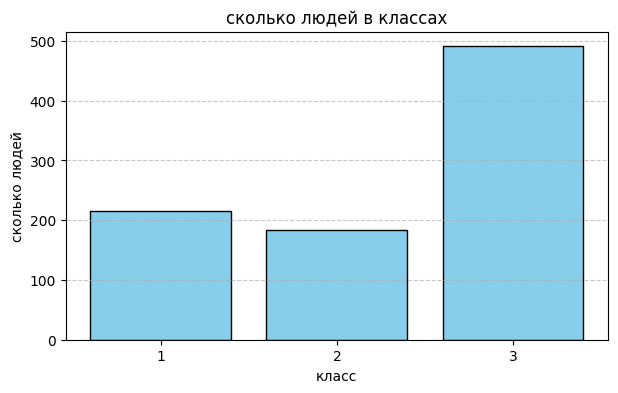

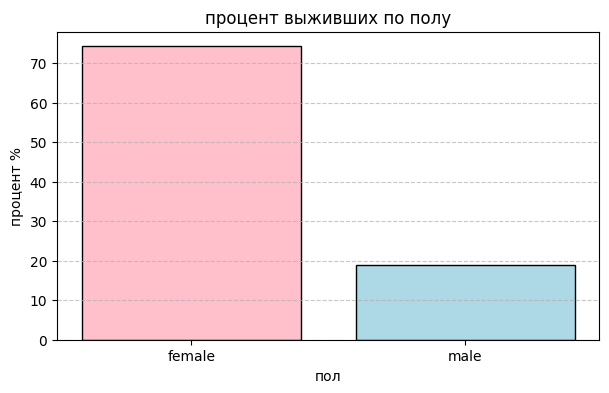


--- свой вопрос ---
вопрос зависела ли выживаемость детей до 18 лет от класса билета
Pclass
1    0.916667
2    0.913043
3    0.371795
Name: Survived, dtype: float64


In [26]:
print("=== задание 6 ===")

# график сколько людей в классах
plt.figure(figsize=(7, 4))
pclass_counts = df["Pclass"].value_counts().sort_index()
plt.bar(pclass_counts.index.astype(str), pclass_counts.values, color="skyblue", edgecolor="black")
plt.title("сколько людей в классах")
plt.xlabel("класс")
plt.ylabel("сколько людей")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# график выживаемости по полу
plt.figure(figsize=(7, 4))
sex_survival = df.groupby("Sex")["Survived"].mean() * 100
plt.bar(sex_survival.index, sex_survival.values, color=["pink", "lightblue"], edgecolor="black")
plt.title("процент выживших по полу")
plt.xlabel("пол")
plt.ylabel("процент %")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# свой вопрос к данным
print("\n--- свой вопрос ---")
print("вопрос зависела ли выживаемость детей до 18 лет от класса билета")
children_df = df[df["Age"] < 18]
print(children_df.groupby("Pclass")["Survived"].mean())
